# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Load Dataset

In [3]:
# Load whichever sheet/file you used in EDA
df = pd.read_csv('../data/raw/data.csv', encoding='latin-1')

# Standardize column names (remove spaces)
df.columns = df.columns.str.strip().str.replace(' ', '')

print(f"Raw shape: {df.shape}")
df.head(3)

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


## Drop Missing values

In [4]:
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print(f"After dropping missing CustomerIDs: {df_clean.shape}")
print(f"Dropped: {len(df) - len(df_clean):,} rows")

After dropping missing CustomerIDs: (406829, 8)
Dropped: 135,080 rows


In [6]:
# Remove cancelled invoices (start with 'C')
df_clean = df_clean[~df_clean['InvoiceDate'].astype(str).str.startswith('C')]

# Remove negative or zero quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove negative or zero prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print(f"After removing cancellations + bad rows: {df_clean.shape}")

After removing cancellations + bad rows: (397884, 8)


In [7]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')

# Drop rows where date parsing failed
df_clean = df_clean.dropna(subset=['InvoiceDate'])

# Filter to realistic date range only (2009–2012)
df_clean = df_clean[
    (df_clean['InvoiceDate'] >= '2009-01-01') &
    (df_clean['InvoiceDate'] <= '2012-12-31')
]

print(f"Date range after fix: {df_clean['InvoiceDate'].min()} → {df_clean['InvoiceDate'].max()}")
print(f"Final clean shape: {df_clean.shape}")

Date range after fix: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Final clean shape: (397884, 8)


In [9]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Total revenue (clean): £{df_clean['Revenue'].sum():,.2f}")

Total revenue (clean): £8,911,407.90


# RFM Table

In [11]:
# Reference date = 1 day after the last transaction
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceDate',     'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape}")
print(f"\nRFM stats:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Reference date: 2011-12-10

RFM table shape: (4338, 4)

RFM stats:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.25    2054.27
std     100.01       7.64    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     210.00  280206.02


# Check Outliers

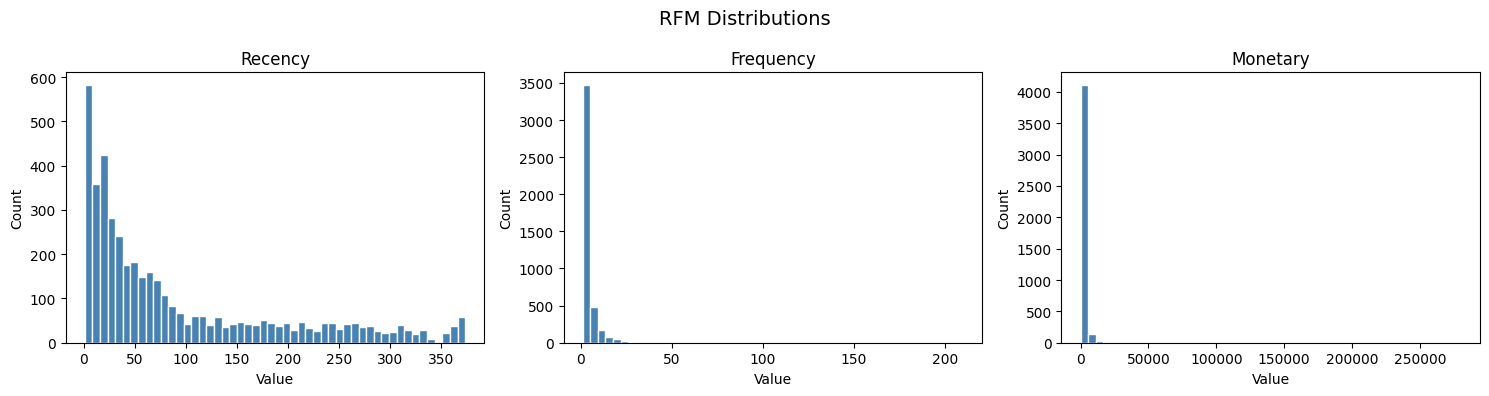

Plot saved ✓


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    ax.hist(rfm[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('RFM Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/rfm_distributions.png', dpi=150)
plt.show()
print("Plot saved ✓")

In [13]:
# Cap Monetary at 99th percentile to reduce skew
cap = rfm['Monetary'].quantile(0.99)
rfm['Monetary'] = rfm['Monetary'].clip(upper=cap)

# Cap Frequency similarly
cap_f = rfm['Frequency'].quantile(0.99)
rfm['Frequency'] = rfm['Frequency'].clip(upper=cap_f)

print("Outliers capped ✓")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Outliers capped ✓
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     92.54       4.00   1598.58
std     100.01       4.83   2797.83
min       1.00       1.00      3.75
25%      18.00       1.00    307.41
50%      51.00       2.00    674.48
75%     142.00       5.00   1661.74
max     374.00      30.00  19881.00


In [14]:
rfm.to_csv('../data/processed/rfm_data.csv', index=False)
print(f"Saved rfm_data.csv with {len(rfm):,} customers ✓")
print("\nPreprocessing complete! Ready for clustering.")

Saved rfm_data.csv with 4,338 customers ✓

Preprocessing complete! Ready for clustering.
